# 04 — Timing summary: every arm, every unit

Part 1 of the test plan, consolidated. Twelve arms of the Monte Carlo nanodisk
simulation measured on **one set of hardware** (Modal: `cpu=8.0` containers and
H100 GPUs), at the production geometry — `Rd=18.30`, `L=5`, `N=39`,
**5,245 active sites** — and the validated skyrmion parameters.

**Which numbers are measured and which are extrapolated.** The five H100 ladder
times are *complete production runs*: 200 temperature points x (10,000 + 5,000)
sweeps, wall clock as reported by the container. Every CPU ladder is extrapolated
from a measured per-sweep cost, which is exact rather than fitted — sweeps run
inside a `fori_loop`, so cost is strictly linear in sweep count. The table marks
each row.

Sources: `01_validation_gpu_vs_prof_dario.ipynb` (the physics agrees with the
tutor's released states), `02_cpu_rate.ipynb`, `03_ablation_dp_bp.ipynb`.
Write-up: `docs/10_ablation_and_cpu_rate.md`.


In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

# Locally the results sit beside the notebook; on Kaggle they arrive as a
# dataset. Rather than hard-code the mount path, find the directory that
# actually holds a known result file -- a dataset can be mounted under a slug
# that does not match its title, and a missing attachment should say so plainly.
ANCHOR = "ablation_8core_v2.json"
def find_results():
    for p in (pathlib.Path("results"),
              pathlib.Path("notebooks/simulation/results"),
              pathlib.Path("/kaggle/input/nanodisk-timing-results")):
        if (p / ANCHOR).exists():
            return p
    root = pathlib.Path("/kaggle/input")
    if root.exists():
        hit = next(root.glob(f"**/{ANCHOR}"), None)
        if hit:
            return hit.parent
        raise FileNotFoundError(
            f"{ANCHOR} not found under /kaggle/input. Mounted: "
            f"{[p.name for p in root.iterdir()]}. Attach the dataset "
            "carloscanamejoy/nanodisk-timing-results.")
    raise FileNotFoundError(f"{ANCHOR} not found and /kaggle/input absent")

RES = find_results()
print("reading from", RES)
load = lambda n: json.load(open(RES / f"{n}.json"))

N_ACTIVE   = 5245            # active sites in the disk
SW_PER_T   = 10_000 + 5_000  # thermalisation + measurement sweeps per temperature
N_TEMPS    = 200             # 20.0 K -> 0.1 K in 0.1 K steps
LADDER     = N_TEMPS * SW_PER_T
DATASET    = 169_671         # states in the tutor's released dataset

print(f"ladder = {N_TEMPS} T-points x {SW_PER_T:,} sweeps = {LADDER:,} sweeps")
print(f"one sweep = {N_ACTIVE:,} single-spin attempts per replica")

reading from results
ladder = 200 T-points x 15,000 sweeps = 3,000,000 sweeps
one sweep = 5,245 single-spin attempts per replica


## The arms — every one at 100 independent chains

Each row is a different *way of doing the same physics*, and every variant
evaluates the identical Hamiltonian, which
`tests/test_ablation_equivalence.py` pins against the reference engine before any
timing is believed.

**All six run 100 independent chains at the production geometry.** Fixing the batch size
once is what lets a single number be compared down a column and across a row,
instead of each bar carrying its own configuration. The full four-by-four grid of
accelerations against devices lives in `03_ablation_dp_bp.ipynb`; what is kept
here are the arms whose ladder and dataset costs are worth extrapolating.

- **MD** — matrix decomposition: the trial energy of many sites as array
  operations instead of arithmetic one site at a time.
- **BP** — the bipartite (checkerboard) update: colouring sites by
  `(x+y+z) mod 2` so no two sites updated together are neighbours.

In [2]:
A    = load("ablation_8core_v2")
# Warm steady state: inside one container the rate improves 16% over four
# repeats, so a cold single shot over-reports. The ladder is one call lasting
# days, so it runs warm throughout.
warm_runs = [r["ms_per_sweep"] for r in load("cpu_rate_repeat")["rows"]]
WARM, WARM_SD = float(np.mean(warm_runs)), float(np.std(warm_runs))

grid = {n: {r["cell"]: r for r in load(t)["rows"]}
        for t, n in (("grid_cpu", "CPU"), ("grid_1gpu", "1x H100"),
                     ("grid_2gpu", "2x H100"), ("grid_4gpu", "4x H100"))}

def gpu(tag):
    g = load(tag)
    return g["ms_per_sweep"], g["replicas"], g["n_devices"], g["elapsed_s"]

ARMS = []
def add(label, ms, devices, ladder_s=None, group="cpu"):
    # No replica argument: every arm here is 100 replicas, stated once below.
    ARMS.append(dict(label=label, ms_sweep=ms, replicas=REPLICAS,
                     devices=devices, ladder_s=ladder_s, group=group))

REPLICAS = 100

# Sequential chains: the cells a GPU cannot help. Shown on both devices so the
# comparison that matters -- an H100 is far WORSE here than a CPU -- is visible.
add("no MD, no BP - 1x H100", grid["1x H100"]["nodp_nobp"]["ms_per_sweep"],
    1, group="broken")
add("no MD, no BP - CPU", grid["CPU"]["nodp_nobp"]["ms_per_sweep"],
    0, group="broken")
# The production kernel, on every device. The CPU row uses the warm rate from
# the repeated measurement rather than the grid's single shot.
add("MD + BP - CPU (warm)", WARM, 0)
for tag, lab, dv in (("A1_1xH100", "MD + BP - 1x H100", 1),
                     ("A2_2xH100", "MD + BP - 2x H100", 2),
                     ("A3_4xH100", "MD + BP - 4x H100", 4)):
    ms, rep, ndev, el = gpu(tag)
    assert rep == REPLICAS, f"{tag} is {rep} replicas, not {REPLICAS}"
    add(lab, ms, dv, ladder_s=el, group="gpu")

print(f"{len(ARMS)} arms, all at {REPLICAS} replicas · "
      f"warm CPU rate {WARM:.1f} +- {WARM_SD:.1f} ms/sweep")

6 arms, all at 100 replicas · warm CPU rate 62.4 +- 4.0 ms/sweep


## The reference, stated once

Every speedup here is quoted against **reference B — no MD, no BP, numpy, 100
replicas, CPU** (3.34 ms per replica-sweep). B is the baseline because it is the
same 100-replica configuration as every other arm, so the comparison is like for
like; a ratio against a differently sized run is not a speedup, it is two
experiments.

**A — 1 replica, pure Python, no MD, no BP, no JAX (12.77 ms per replica-sweep)
is declared separately and is not the reference.** It is 3.8x slower per replica
than B for a reason unrelated to either acceleration under study: B's replica
axis is already an array dimension. Quoting against A would inflate every factor
by 3.8x against a program nobody ran. Full derivation in
`03_ablation_dp_bp.ipynb`.

**Hardware.** Modal, container `cpu=8.0`, x86-64 GenuineIntel, 24 visible vCPUs,
gVisor; GPU arms on **NVIDIA H100 80GB HBM3** (driver 580.95.05, compute 9.0).
The CPU *model name* is reported as `unknown` by the environment — gVisor masks
it — so it is not quotable. `cpu=8.0` caps CPU time by cgroup without capping
visibility, so numpy and JAX size their thread pools to 24 vCPUs while throttled
to 8 cores' worth; that likely contributes to the ~20% between-container
scatter.

In [3]:
HW = load("hardware")
print(f"CPU: {HW['cpu_container']['model_name']}, "
      f"{HW['cpu_container']['visible_vcpus']} visible vCPUs "
      f"({HW['cpu_container']['requested']} requested)")
print(f"GPU: {HW['gpu_container']['gpu']}, "
      f"driver {HW['gpu_container']['driver_version']}\n")

grid_cpu_ref = grid["CPU"]["nodp_nobp"]["ms_per_sweep"]
REF_B = grid_cpu_ref / REPLICAS
REF_A = [r for r in A["cells"] if r["cell"] == "nodp_nobp"][0]["ms_per_sweep"]
print(f"reference B (no MD, no BP, numpy, {REPLICAS} repl): "
      f"{REF_B:.4f} ms/replica-sweep")
print(f"declared  A (no MD, no BP, Python, 1 repl):   "
      f"{REF_A:.4f} ms/replica-sweep  ({REF_A/REF_B:.1f}x slower)")

CPU: unknown (masked by gVisor), 24 visible vCPUs (cpu=8.0 requested)
GPU: NVIDIA H100 80GB HBM3, driver 580.95.05

reference B (no MD, no BP, numpy, 100 repl): 3.3410 ms/replica-sweep
declared  A (no MD, no BP, Python, 1 repl):   12.7709 ms/replica-sweep  (3.8x slower)


## Every comparable time unit

A per-sweep number alone cannot be compared across arms, because a sweep covers
a different amount of work depending on the replica count. These are the units
that *are* comparable, from the atomic one upward.

In [4]:
def derive(a):
    ms, rep, dev = a["ms_sweep"], a["replicas"], a["devices"]
    ladder = a["ladder_s"] if a["ladder_s"] else ms * LADDER / 1000
    return dict(
        a,
        # 1. the atomic unit: one single-spin Metropolis attempt. The only unit
        #    that is directly comparable across every arm, batch and device.
        ns_attempt   = ms * 1e6 / (N_ACTIVE * rep),
        # 2. one sweep (MCS) of the whole lattice, as the arm was run.
        ms_sweep     = ms,
        # 3. per sweep per replica: removes the batch size.
        ms_sweep_rep = ms / rep,
        # 4. one temperature point = 15,000 sweeps.
        s_per_T      = ms * SW_PER_T / 1000,
        # 5. one finished annealed state. This is the unit dataset generation is
        #    billed in, and the one the paper should quote.
        s_per_state  = ladder / rep,
        # 6. the whole 200-point ladder.
        ladder_s     = ladder,
        measured     = a["ladder_s"] is not None,
        # 7. throughput, the standard HPC figure of merit.
        mups         = N_ACTIVE * rep / (ms / 1000) / 1e6,
        # 8. device-hours per 1000 states: price-independent cost proxy.
        devh_1k      = ladder / rep * 1000 / 3600 * max(dev, 1),
        # 9. regenerating the tutor's released dataset.
        dataset_s    = ladder / rep * DATASET)

D = [derive(a) for a in ARMS]

def human(s):
    for lim, div, u in ((3.15e7, 3.15e7, "yr"), (1.73e5, 86400, "d"),
                        (3600, 3600, "h"), (60, 60, "min"), (1, 1, "s")):
        if s > lim: return f"{s/div:.1f} {u}"
    return f"{s*1000:.0f} ms"

hdr = (f"{'arm':26s}{'ns/att':>12}{'ms/sweep':>12}{'ms/sw/rep':>12}"
       f"{'s/T-pt':>12}{'s/state':>12}{'ladder':>11}{'':>3}{'M upd/s':>10}")
print(hdr); print("-" * len(hdr))
for d in D:
    print(f"{d['label']:26s}{d['ns_attempt']:12,.2f}"
          f"{d['ms_sweep']:12,.3f}{d['ms_sweep_rep']:12,.4f}{d['s_per_T']:12,.1f}"
          f"{d['s_per_state']:12,.1f}{human(d['ladder_s']):>11}"
          f"{'  M' if d['measured'] else '  e':>3}{d['mups']:10,.2f}")
print("\n  M = measured wall clock of a complete production ladder")
print("  e = extrapolated from a measured per-sweep cost (exactly linear in sweeps)")

arm                             ns/att    ms/sweep   ms/sw/rep      s/T-pt     s/state     ladder      M upd/s
--------------------------------------------------------------------------------------------------------------
no MD, no BP - 1x H100      278,960.82 146,314.949  1,463.1495 2,194,724.2 4,389,448.5    13.9 yr  e      0.00
no MD, no BP - CPU              636.99     334.102      3.3410     5,011.5    10,023.1     11.6 d  e      1.57
MD + BP - CPU (warm)            118.88      62.354      0.6235       935.3     1,870.6      2.2 d  e      8.41
MD + BP - 1x H100                 0.58       0.303      0.0030         4.5         9.1   15.1 min  M  1,731.84
MD + BP - 2x H100                 0.25       0.133      0.0013         2.0         4.0    6.6 min  M  3,948.48
MD + BP - 4x H100                 0.16       0.084      0.0008         1.3         2.5    4.2 min  M  6,231.92

  M = measured wall clock of a complete production ladder
  e = extrapolated from a measured per-sweep cost (ex

### Reading the units

- **A per-sweep number is not comparable on its own.** A sweep covers one
  replica's lattice or four hundred, so `ms/sweep` only means something next to
  the replica count — which is why every label below carries it.
- **ns per attempt** is the only unit comparable across everything. A single-spin
  Metropolis attempt costs 0.58 ns on one H100 at 100 independent chains against 119 ns on
  the CPU kernel and 2,435 ns in a scalar Python loop.
- **s per state** is what dataset generation is actually billed in, and the
  number the paper should quote: one finished annealed state in **9.1 s** on one
  H100, **2.5 s** on four, **31 min** on CPU.
- **M upd/s** (million lattice updates per second) is the standard HPC figure of
  merit and makes this comparable to published Monte Carlo codes.

## Cost per 1000 states, and why more GPUs do not reduce it

In [5]:
print(f"{'arm':26s}{'s/state':>12}{'per 1000 states':>18}"
      f"{'regenerate 169,671':>21}")
print("-" * 81)
for d in D:
    unit = "GPU-h" if d["devices"] else "CPU-h"
    print(f"{d['label']:26s}{d['s_per_state']:12,.1f}"
          f"{d['devh_1k']:12,.1f} {unit:5s}{human(d['dataset_s']):>21}")

g = [d for d in D if d["group"] == "gpu"]
print("\nGPU-hours per 1000 states across every GPU configuration:")
print("  " + ", ".join(f"{d['label'].split('- ')[-1]}: {d['devh_1k']:.1f}" for d in g))
print(f"  spread {min(x['devh_1k'] for x in g):.1f}-{max(x['devh_1k'] for x in g):.1f} "
      f"-> flat within the ~15% run-to-run scatter.")
print("\nBilling is per device-second, so adding GPUs buys WALL CLOCK, not money.")

arm                            s/state   per 1000 states   regenerate 169,671
---------------------------------------------------------------------------------
no MD, no BP - 1x H100     4,389,448.5 1,219,291.2 GPU-h           23643.2 yr
no MD, no BP - CPU            10,023.1     2,784.2 CPU-h              54.0 yr
MD + BP - CPU (warm)           1,870.6       519.6 CPU-h              10.1 yr
MD + BP - 1x H100                  9.1         2.5 GPU-h               17.8 d
MD + BP - 2x H100                  4.0         2.2 GPU-h                7.8 d
MD + BP - 4x H100                  2.5         2.8 GPU-h                5.0 d

GPU-hours per 1000 states across every GPU configuration:
  1x H100: 2.5, 2x H100: 2.2, 4x H100: 2.8
  spread 2.2-2.8 -> flat within the ~15% run-to-run scatter.

Billing is per device-second, so adding GPUs buys WALL CLOCK, not money.


**More GPUs buy latency, not cost.** Hold the work fixed — one 200-point ladder
at 100 independent chains — and go from 1 to 4 H100: it finishes **3.6x sooner** (15.1 min
to 4.2) while the bill stays the same, because billing is per device-second and
you rented four of them for a quarter of the time.

That follows from the scaling result rather than being a separate finding:
replicas are independent chains with no collective, so multi-GPU efficiency is
~1 and nothing is gained or lost per unit of work.

**So the GPU count is a deadline decision, not a budget one.** Rent four when
you need the answer today; rent one when you do not. The budget is set by how
many states you need, not by how fast you want them.

(The 25- and 400-replica runs are deliberately excluded here. They vary batch
size, not GPU count, and mixing the two on one axis is what made an earlier
version of this chart unreadable.)

## The ablation, by device

Eleven bars, **all at 100 independent chains**. The CPU carries the full four-cell
ablation because it is the reference device; each GPU configuration carries only
the cells that still say something new.

`no MD, BP` is dropped from the GPU groups because it is redundant with
`no MD, no BP` — BP costs 0.98x *in a scalar implementation* (and 2.02x in the vectorised one that ships — see `03_ablation_dp_bp.ipynb`), established on CPU and confirmed on every device
in `03_ablation_dp_bp.ipynb`. For 2x and 4x the pair kept is the one that matters:
**more GPUs make the sequential cell worse and the production cell better.**

Speed against **reference B** is printed under each bar; `1/N` means N times
*slower* than B.

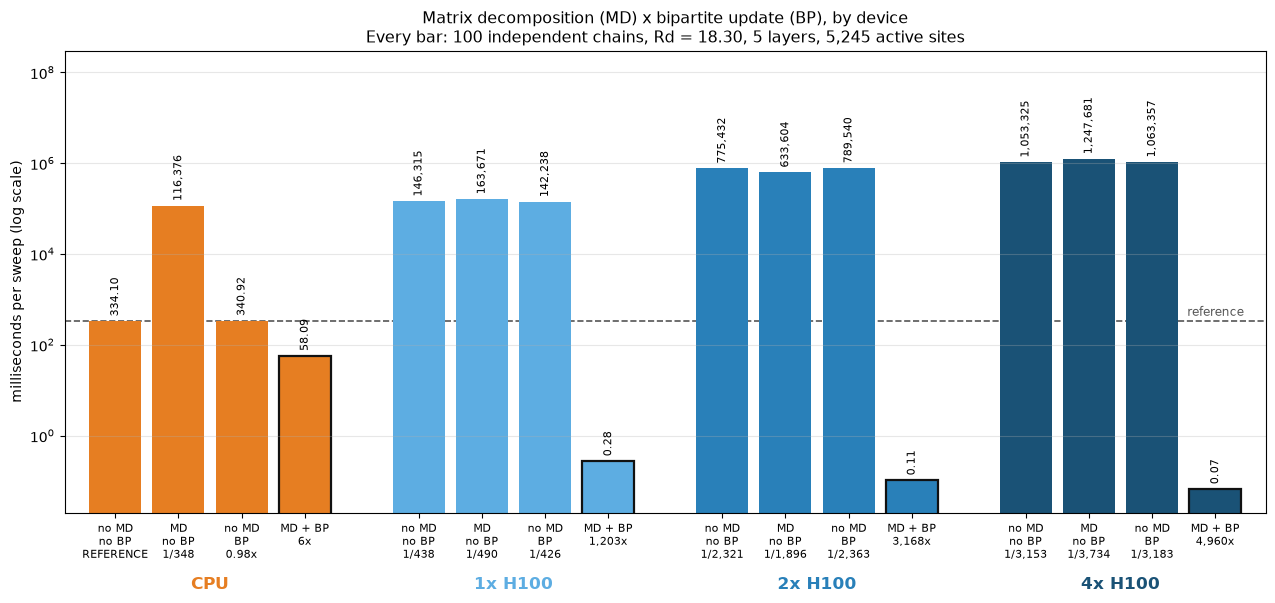

In [6]:
import matplotlib.transforms as mtrans

SHORT = {"nodp_nobp": "no MD\nno BP", "dp_nobp": "MD\nno BP",
         "nodp_bp": "no MD\nBP", "dp_bp": "MD + BP"}
CELLS4 = ["nodp_nobp", "dp_nobp", "nodp_bp", "dp_bp"]
PLAN = [(dev, CELLS4) for dev in ("CPU", "1x H100", "2x H100", "4x H100")]
CDEV = {"CPU": "#e67e22", "1x H100": "#5dade2",
        "2x H100": "#2980b9", "4x H100": "#1a5276"}
REF_CELL = ("CPU", "nodp_nobp")


def ablation_chart(value, ylabel, title, fmt, ylim, ratio_from_value=False):
    """The 11-bar layout, drawn from one place so both charts stay identical.

    `value` maps a grid row to the quantity plotted; the speed ratios underneath
    always come from ms/sweep, so the two charts carry the same ratios in
    different units.
    """
    xs, vals, ticks, cols, edges, groups = [], [], [], [], [], []
    _ref_value = (value(grid[REF_CELL[0]][REF_CELL[1]], REF_CELL)
                  if ratio_from_value else None)
    x = 0.0
    for dev, cells in PLAN:
        start = x
        for c in cells:
            row = grid[dev][c]
            v = value(row, (dev, c)) if ratio_from_value else value(row)
            # The ratio must come from the quantity actually plotted, or a bar
            # built from a measured ladder would carry a ratio derived from
            # something else.
            sp = ((_ref_value / v) if ratio_from_value
                  else REF_B / (row["ms_per_sweep"] / REPLICAS))
            tag = ("REFERENCE" if (dev, c) == REF_CELL
                   else f"{sp:,.0f}x" if sp >= 1.05
                   else f"{sp:.2f}x" if sp >= 0.5 else f"1/{1/sp:,.0f}")
            xs.append(x); vals.append(v if ratio_from_value else value(row))
            cols.append(CDEV[dev])
            # A bold outline marks a bar whose value was measured directly.
            meas = ratio_from_value and (dev, c) in MEASURED
            edges.append("#111" if (c == "dp_bp" and (meas or not ratio_from_value))
                         else "none")
            ticks.append(f"{SHORT[c]}\n{tag}")
            x += 1
        groups.append((dev, (start + x - 1) / 2))
        x += 0.8

    fig, ax = plt.subplots(figsize=(15.5, 7))
    ax.bar(xs, vals, 0.82, color=cols, edgecolor=edges, linewidth=1.6)
    for xi, v in zip(xs, vals):
        ax.text(xi, v * 1.45, fmt(v), ha="center", fontsize=8, rotation=90)
    ref = (value(grid[REF_CELL[0]][REF_CELL[1]], REF_CELL) if ratio_from_value
           else value(grid[REF_CELL[0]][REF_CELL[1]]))
    ax.axhline(ref, ls="--", lw=1.2, color="#555", zorder=0)
    ax.text(xs[-1] + 0.45, ref * 1.3, "reference", fontsize=8.5,
            color="#555", ha="right")
    ax.set_xticks(xs); ax.set_xticklabels(ticks, fontsize=7.8)
    ax.set_xlim(-0.8, xs[-1] + 0.8)
    ax.set_yscale("log"); ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11.5)
    ax.grid(axis="y", which="major", alpha=0.3)
    # Device names in axes coordinates, below the ticks, so no bar covers them.
    tr = mtrans.blended_transform_factory(ax.transData, ax.transAxes)
    for dev, cx in groups:
        ax.text(cx, -0.165, dev, transform=tr, ha="center", fontsize=12,
                weight="bold", color=CDEV[dev], clip_on=False)
    plt.subplots_adjust(bottom=0.22)
    plt.show()


ablation_chart(
    value=lambda r: r["ms_per_sweep"],
    ylabel="milliseconds per sweep (log scale)",
    title="Matrix decomposition (MD) x bipartite update (BP), by device\n"
          "Every bar: 100 independent chains, Rd = 18.30, 5 layers, "
          "5,245 active sites",
    fmt=lambda v: f"{v:,.2f}" if v < 1000 else f"{v:,.0f}",
    ylim=(0.02, 3e8))

## Total time for one complete ladder

The same eleven bars, the same layout, one unit up: not the cost of a sweep but
of a whole 200-point production run. Nothing is re-measured — cost is exactly
linear in sweeps, so this is the previous chart multiplied by 3,000,000.

Reading it next to the one above is the point: a difference that looks like a
factor on a log axis is the difference between **four minutes and a century**.

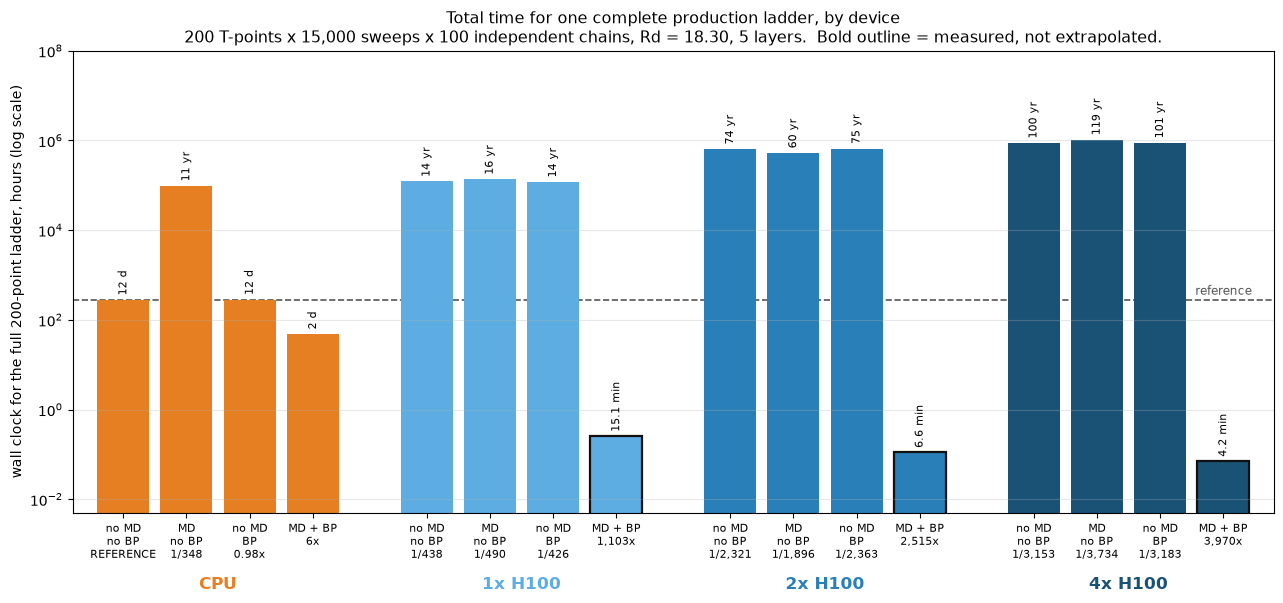

full ladder = 3,000,000 sweeps at 100 independent chains

device    cell                ladder  source
----------------------------------------------------
CPU       no MD + no BP         12 d  extrapolated
CPU       MD + no BP           11 yr  extrapolated
CPU       no MD + BP            12 d  extrapolated
CPU       MD + BP                2 d  extrapolated
1x H100   no MD + no BP        14 yr  extrapolated
1x H100   MD + no BP           16 yr  extrapolated
1x H100   no MD + BP           14 yr  extrapolated
1x H100   MD + BP           15.1 min  MEASURED
2x H100   no MD + no BP        74 yr  extrapolated
2x H100   MD + no BP           60 yr  extrapolated
2x H100   no MD + BP           75 yr  extrapolated
2x H100   MD + BP            6.6 min  MEASURED
4x H100   no MD + no BP       100 yr  extrapolated
4x H100   MD + no BP          119 yr  extrapolated
4x H100   no MD + BP          101 yr  extrapolated
4x H100   MD + BP            4.2 min  MEASURED


In [7]:
# Where a complete production ladder was actually run, its measured wall clock
# is used. The grid times a tight update-only loop; a real ladder also computes
# every observable on every measurement sweep, so the grid is 9-26% optimistic:
# 4x H100 reads 3.4 min derived against 4.2 min measured. Deriving all eleven
# bars for layout tidiness quietly replaced three measurements with estimates,
# and understated the production runs.
MEASURED = {}
for tag, dev in (("A1_1xH100", "1x H100"), ("A2_2xH100", "2x H100"),
                 ("A3_4xH100", "4x H100")):
    r = load(tag)
    assert r["replicas"] == REPLICAS, f"{tag} is not {REPLICAS} chains"
    MEASURED[(dev, "dp_bp")] = r["elapsed_s"] / 3600


def _hours(row, key=None):
    if key in MEASURED:
        return MEASURED[key]
    return row["ms_per_sweep"] * LADDER / 3.6e6


def _ht(h):
    if h > 8760:  return f"{h/8760:,.0f} yr"
    if h > 48:    return f"{h/24:,.0f} d"
    if h < 1:     return f"{h*60:.1f} min"
    return f"{h:,.1f} h"


ablation_chart(
    value=_hours,
    ylabel="wall clock for the full 200-point ladder, hours (log scale)",
    title="Total time for one complete production ladder, by device\n"
          "200 T-points x 15,000 sweeps x 100 independent chains, "
          "Rd = 18.30, 5 layers.  Bold outline = measured, not extrapolated.",
    fmt=_ht,
    ylim=(5e-3, 1e8),
    ratio_from_value=True)

print(f"full ladder = {LADDER:,} sweeps at {REPLICAS} independent chains\n")
print(f"{'device':10s}{'cell':16s}{'ladder':>10}  source")
print("-" * 52)
for dev, cells in PLAN:
    for c in cells:
        key = (dev, c)
        h = _hours(grid[dev][c], key)
        src = "MEASURED" if key in MEASURED else "extrapolated"
        print(f"{dev:10s}{SHORT[c].replace(chr(10), ' + '):16s}{_ht(h):>10}  {src}")

### Why a real ladder costs more than the grid says

Deriving the ladder times from the grid understated 4x H100 as 3.4 min against
4.2 min measured. "It is the observables" was a guess, so it was measured: the
bare update loop and the full `anneal` timed on **one container each**, so the
difference cannot be run-to-run scatter.

| devices | update | full anneal | overhead | update scaling | overhead scaling |
|---|---|---|---|---|---|
| 1x | 0.2773 ms | 0.3000 ms | +8.2% | 1.00x | 1.00x |
| 2x | 0.1010 | 0.1164 | +15.3% | **2.75x** | **1.48x** |
| 4x | 0.0587 | 0.0699 | +19.1% | **4.72x** | **2.03x** |

On one GPU the full anneal reads 0.3000 against the production ladder's 0.3029 —
a 1% match, so the overhead *is* the observables.

**But the interesting part is why it grows with device count.** The update
divides cleanly across devices (4.72x on four, ideal 4x, the excess inside the
~15% scatter) because replicas are independent chains. The observables are
*reductions* — energy, magnetisation, topological charge — and a reduction
carries a fixed launch cost that does not shrink when the array does. At 25
chains per device instead of 100 each reduction handles a quarter of the data and
pays the same launch, so overhead scales only 2.03x.

That is Amdahl's law in plain sight: as devices divide the parallel part, the
fixed part comes to dominate, and the overhead rises from 8.2% to 19.1%.

The residual (2x and 4x still 14-20% under the production ladder) is the ladder
length: this test ran 10 temperature points against production's 200, so the
`scan` stacks twenty times less output, plus the cross-device concatenate at the
end, plus the usual scatter.

## The three normalised units, side by side

Per-attempt, per-state and throughput are all **per-chain** quantities, so these
three panels are directly comparable across devices and need no reference line.

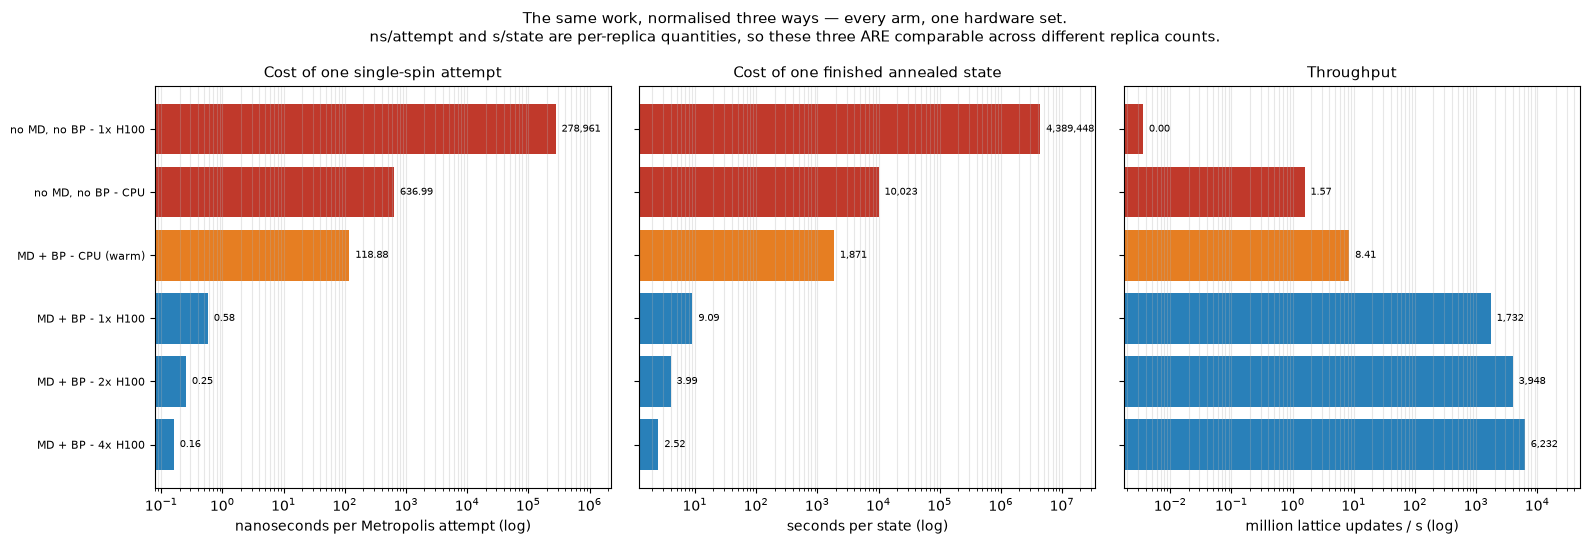

In [8]:
C = {"gpu": "#2980b9", "cpu": "#e67e22", "broken": "#c0392b"}
lab = [d["label"] for d in D]
col = [C[d["group"]] for d in D]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, key, title, xlabel in (
        (axes[0], "ns_attempt", "Cost of one single-spin attempt",
         "nanoseconds per Metropolis attempt (log)"),
        (axes[1], "s_per_state", "Cost of one finished annealed state",
         "seconds per state (log)"),
        (axes[2], "mups", "Throughput", "million lattice updates / s (log)")):
    v = [d[key] for d in D]
    bb = ax.barh(range(len(D)), v, color=col)
    ax.set_yticks(range(len(D)))
    ax.set_yticklabels(lab if ax is axes[0] else [], fontsize=8)
    ax.invert_yaxis(); ax.set_xscale("log")
    ax.set_xlabel(xlabel); ax.set_title(title, fontsize=11)
    ax.grid(axis="x", which="both", alpha=0.3)
    ax.set_xlim(right=max(v) * 8)
    for r, x in zip(bb, v):
        ax.text(x * 1.25, r.get_y() + r.get_height() / 2,
                f"{x:,.2f}" if x < 1000 else f"{x:,.0f}",
                va="center", fontsize=7)
fig.suptitle("The same work, normalised three ways — every arm, one hardware set.\n"
             "ns/attempt and s/state are per-replica quantities, so these three "
             "ARE comparable across different replica counts.", fontsize=11)
plt.tight_layout(); plt.show()

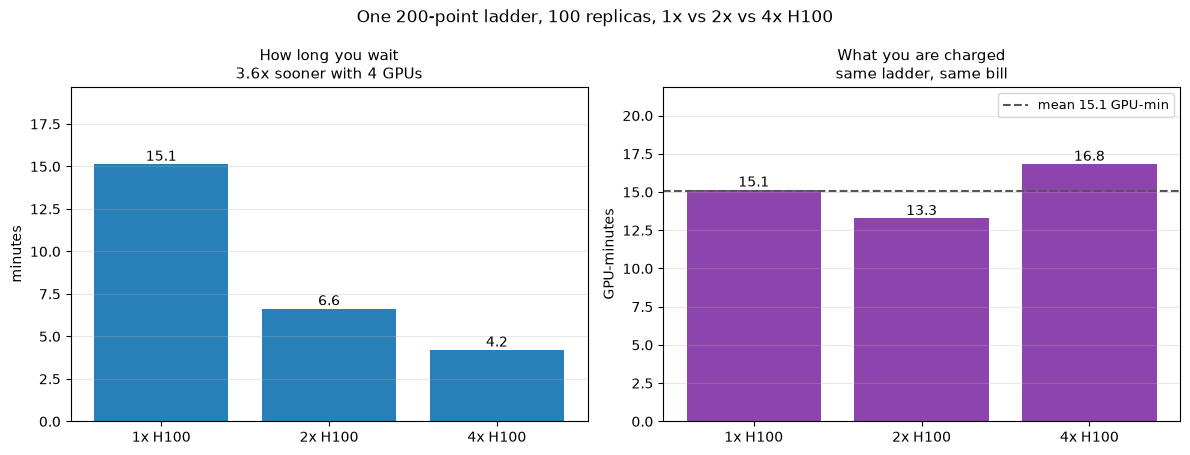

the same ladder, 100 replicas, on 1 / 2 / 4 H100:
  1x H100   finishes in  15.1 min  and charges  15.1 GPU-minutes
  2x H100   finishes in   6.6 min  and charges  13.3 GPU-minutes
  4x H100   finishes in   4.2 min  and charges  16.8 GPU-minutes

4x H100 finishes 3.6x sooner and charges 1.11x as much -- flat inside the ~15% scatter.
Replicas are independent chains with no collective, so multi-GPU
efficiency is ~1: nothing is gained or lost per unit of work.


In [9]:
# Cost vs latency, at a FIXED 100 replicas. An earlier version of this chart put
# the 25- and 400-replica runs on the same axis, which made "wall clock falls"
# false: on one H100 it goes 4.2 -> 15.1 -> 56.9 min as replicas rise, because
# that is more work, not less. Varying GPU count and batch size on one axis
# answers neither question. Batch scaling is its own study; this is GPU count.
fixed = [d for d in D if d["group"] == "gpu"]   # all arms are 100 replicas
fixed.sort(key=lambda d: d["devices"])
names = [f"{d['devices']}x H100" for d in fixed]
wall  = [d["ladder_s"] / 60 for d in fixed]
# Billing is per device-second, so what the ladder costs is wall clock times the
# number of devices rented. Expressed as GPU-minutes it needs no price.
charged = [d["ladder_s"] / 60 * d["devices"] for d in fixed]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, v, c, title, ylab in (
        (axes[0], wall, "#2980b9",
         f"How long you wait\n{wall[0]/wall[-1]:.1f}x sooner with 4 GPUs", "minutes"),
        (axes[1], charged, "#8e44ad",
         "What you are charged\nsame ladder, same bill", "GPU-minutes")):
    b = ax.bar(range(len(fixed)), v, color=c)
    ax.set_xticks(range(len(fixed))); ax.set_xticklabels(names, fontsize=10)
    ax.set_ylabel(ylab); ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(v) * 1.3)
    for i, x in enumerate(v):
        ax.text(i, x, f"{x:.1f}", ha="center", va="bottom", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
axes[1].axhline(np.mean(charged), ls="--", color="#555",
                label=f"mean {np.mean(charged):.1f} GPU-min")
axes[1].legend(fontsize=9)
fig.suptitle("One 200-point ladder, 100 replicas, 1x vs 2x vs 4x H100", fontsize=12)
plt.tight_layout(); plt.show()

print("the same ladder, 100 replicas, on 1 / 2 / 4 H100:")
for n, w, c in zip(names, wall, charged):
    print(f"  {n:9s} finishes in {w:5.1f} min  and charges {c:5.1f} GPU-minutes")
print(f"\n4x H100 finishes {wall[0]/wall[-1]:.1f}x sooner and charges "
      f"{charged[-1]/charged[0]:.2f}x as much -- flat inside the ~15% scatter.")
print("Replicas are independent chains with no collective, so multi-GPU")
print("efficiency is ~1: nothing is gained or lost per unit of work.")

## Declared limits

- **Run-to-run scatter is ~15% on GPU and must be declared.** Each GPU arm is one
  complete ladder, measured once. No difference smaller than that is real.
- **CPU rows are extrapolated**, from a warm rate of 62.4 ± 4.0 ms/sweep. Cold
  containers over-report by ~1.6x; the earlier 97.4 and 143 ms/sweep figures are
  retired, as are the 265x and 322x speedups derived from them.
- **The scalar arms are CPython.** 8.6x is the gain over a straightforward
  *Python* site-by-site loop — which is what the group has — not over a compiled
  sequential implementation, which would narrow the gap substantially.
- **`MD + BP (numpy)` is 1 replica, float64**, not the shipped kernel.
  The production kernel is JAX float32 and on CPU is *slower* than numpy at batch
  1. The ablation is reported in numpy so MD is the only thing varying.
- **The checkerboard is exact only for shells 1 and 3.** Shells 2 and 4 connect
  same-parity sites, so with `J2` or `J4` non-zero the simultaneous update is not
  an exact reordering of sequential Metropolis. These runs have `J2=J3=J4=0`;
  **18.9% of the released dataset does not**, and that bias is unmeasured. Open
  question for the tutor.